# 4-Hour Google Colab Hands-on Tutorial  
## Supervised Learning Regression Project: House Price Prediction

**Project theme:** You are working as a junior ML engineer for a real-estate analytics company.  
Your task is to build a supervised machine learning regression model that predicts house prices using housing and location-related features.

This notebook is designed for a **4-hour instructor-led hands-on session**.

---

## What students will learn

By the end of this session, learners will be able to:

1. Explain supervised learning and regression in simple terms.
2. Understand the end-to-end machine learning lifecycle.
3. Load and explore a real regression dataset.
4. Prepare data for machine learning.
5. Train baseline and advanced regression models.
6. Evaluate regression models using MAE, RMSE, and R² score.
7. Tune a model using cross-validation.
8. Save the trained model and make predictions on new data.
9. Understand how to present ML project results.

# 4-Hour Tutorial Agenda

| Time | Module | Focus |
|---:|---|---|
| 0:00 - 0:25 | Module 1 | Introduction to supervised learning and regression |
| 0:25 - 0:55 | Module 2 | Problem statement and dataset understanding |
| 0:55 - 1:35 | Module 3 | Exploratory Data Analysis |
| 1:35 - 2:10 | Module 4 | Data preprocessing and train-test split |
| 2:10 - 2:55 | Module 5 | Model building: baseline, linear regression, tree models |
| 2:55 - 3:25 | Module 6 | Model evaluation and comparison |
| 3:25 - 3:50 | Module 7 | Hyperparameter tuning and model saving |
| 3:50 - 4:00 | Module 8 | Final discussion, assignment, and Q&A |

---

## Teaching approach

Use this structure for every module:

1. Explain the concept in layman terms.
2. Run the code cell.
3. Ask students to observe the output.
4. Discuss why the step is important in a real ML project.
5. Give a small task before moving to the next section.

# Module 1: Supervised Learning and Regression

## What is supervised learning?

Supervised learning means we train a machine learning model using examples where the correct answer is already known.

For example:

| Input Data | Correct Answer |
|---|---|
| House size, location, income level nearby | House price |
| Student study hours, attendance, previous marks | Exam score |
| Customer age, salary, past spending | Loan amount |

The model learns the relationship between input features and the target output.

---

## What is regression?

Regression is a type of supervised learning where the target value is a **number**.

Examples:

- Predicting house price
- Predicting sales revenue
- Predicting salary
- Predicting electricity consumption
- Predicting delivery time

In this tutorial, we will predict **house price**, so this is a **supervised regression problem**.

# Project Problem Statement

## Business Problem

A real-estate analytics company wants to estimate house prices based on district-level housing features such as income, house age, rooms, population, and location.

Currently, price estimation is manual and inconsistent. The business wants a machine learning model that can give a quick estimated house price.

---

## ML Problem

Build a supervised regression model to predict the median house value using historical housing data.

---

## Target variable

`MedHouseVal` = Median house value

In the California Housing dataset, this target value is represented in units of **$100,000**.

Example:

- `2.5` means approximately `$250,000`
- `4.0` means approximately `$400,000`

---

## Success Criteria

A good model should:

1. Have low prediction error.
2. Explain house value patterns reasonably.
3. Generalize well on unseen data.
4. Be easy to save and reuse for new predictions.

# End-to-End ML Project Lifecycle

In this hands-on tutorial, we will follow this flow:

1. Problem understanding  
2. Dataset loading  
3. Data understanding  
4. Exploratory Data Analysis  
5. Data preprocessing  
6. Train-test split  
7. Model training  
8. Model evaluation  
9. Model improvement  
10. Model saving  
11. New prediction  

This is the same high-level lifecycle followed in real-world machine learning projects.

# Module 2: Environment Setup

Run the following cell in Google Colab.

Most packages are already available in Colab, but this cell ensures required libraries are installed.

In [43]:
# Install required libraries
!pip -q install pandas numpy matplotlib scikit-learn joblib

In [44]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings

warnings.filterwarnings("ignore")

# Scikit-learn imports
from sklearn.datasets import fetch_california_housing, make_regression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


# Load the Dataset

We will use the California Housing dataset available through scikit-learn.

The dataset contains district-level housing data from California.  
Each row represents a block group/district, not one individual house.

If the dataset download fails in Colab due to internet issues, the notebook will create a synthetic fallback dataset so the tutorial can continue.

In [45]:
# Load California Housing dataset with fallback option
try:
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame.copy()
    print("California Housing dataset loaded successfully")
except Exception as e:
    print("Could not load California Housing dataset. Creating fallback synthetic regression dataset.")
    X, y = make_regression(
        n_samples=5000,
        n_features=8,
        noise=25,
        random_state=42
    )
    feature_names = [
        "MedInc", "HouseAge", "AveRooms", "AveBedrms",
        "Population", "AveOccup", "Latitude", "Longitude"
    ]
    df = pd.DataFrame(X, columns=feature_names)
    df["MedHouseVal"] = y / 100000
    df["MedHouseVal"] = df["MedHouseVal"] - df["MedHouseVal"].min() + 0.5

df.head()

California Housing dataset loaded successfully


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [46]:
# Check dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20640
Number of columns: 9


## Dataset Column Meaning

| Column | Meaning |
|---|---|
| `MedInc` | Median income in the area |
| `HouseAge` | Median age of houses |
| `AveRooms` | Average number of rooms |
| `AveBedrms` | Average number of bedrooms |
| `Population` | Population of the area |
| `AveOccup` | Average number of occupants |
| `Latitude` | Latitude location |
| `Longitude` | Longitude location |
| `MedHouseVal` | Median house value, target variable |

---

## Student Task 1

Answer these questions:

1. Which column is the target variable?
2. Is this a classification or regression problem?
3. Why is house price prediction a regression problem?

Target Variable
The target variable is MedHouseVal, which represents the median house value for a given area. All other columns—MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, and Longitude—are input features used to predict this value.

Problem Type
This is a regression problem, since the goal is to predict a continuous numeric value (median house value) rather than sort data into discrete categories. The dataset is specifically designed to predict median housing prices of California districts based on the available features.

Why This Is Regression
House price prediction qualifies as regression because MedHouseVal can take on any continuous numeric value within a range—not a fixed set of labels—making the problem fundamentally about estimating a quantity rather than classifying an item into a category. For instance, the model must learn how factors like median income, house age, and average rooms per household relate to a home's median value, then output a specific numeric prediction (e.g., a value like 2.5 representing $250,000 in the dataset's scaled units).

This is different from classification, where the output would be a discrete label (like "expensive" vs. "affordable"); since success here is measured by how close the predicted number is to the actual median value, this task requires the continuous, numeric-output approach that defines regression.

# Module 3: Exploratory Data Analysis

Exploratory Data Analysis, or EDA, means understanding the data before building the model.

We will check:

1. Data types
2. Missing values
3. Summary statistics
4. Target distribution
5. Feature relationships
6. Correlation

In [47]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [48]:
# Check missing values
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [49]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## Understanding the target variable

Before model building, always understand the target variable.

Here, the target is `MedHouseVal`.

In [50]:
# Target variable summary
df["MedHouseVal"].describe()

,MedHouseVal
count,20640.000000
mean,2.068558
std,1.153956
min,0.149990
25%,1.196000
50%,1.797000
75%,2.647250
max,5.000010


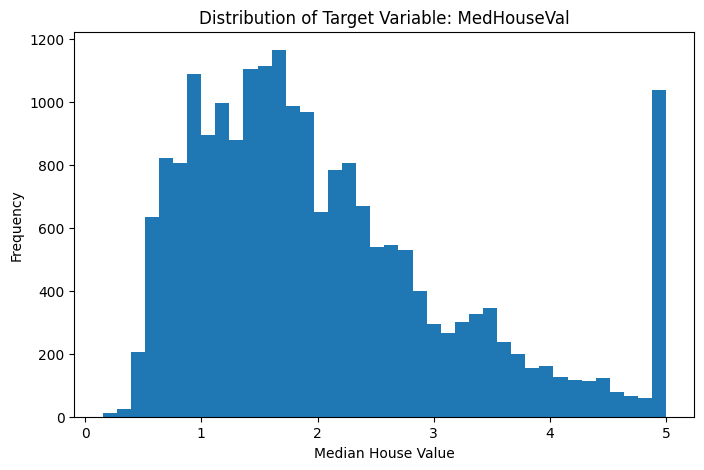

In [51]:
# Plot target distribution
plt.figure(figsize=(8, 5))
plt.hist(df["MedHouseVal"], bins=40)
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable: MedHouseVal")
plt.show()

## Feature Distribution

Now we will visualize the distribution of selected input features.

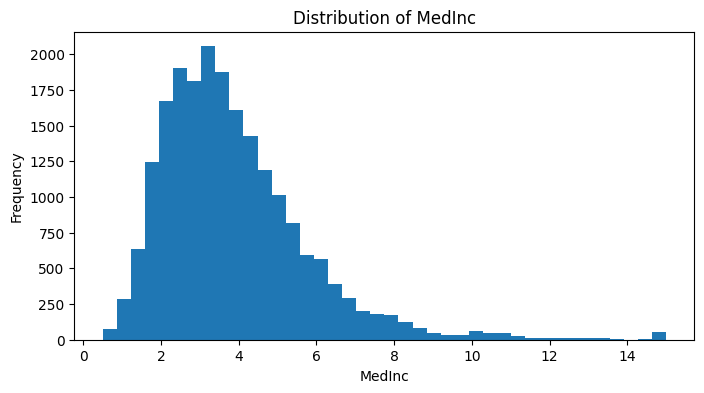

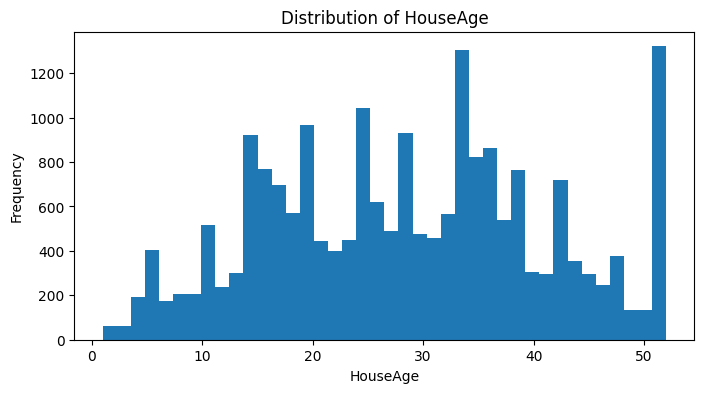

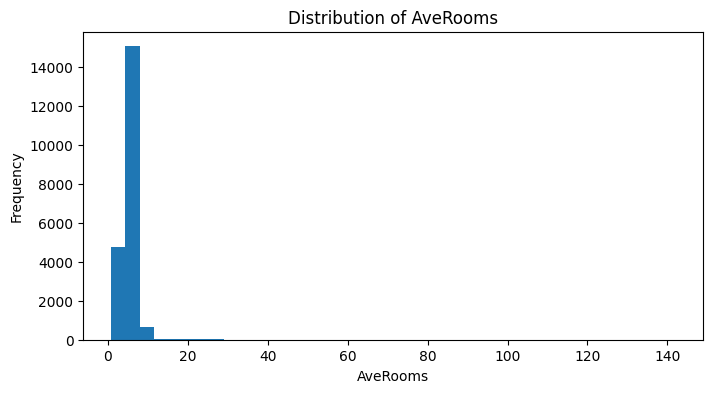

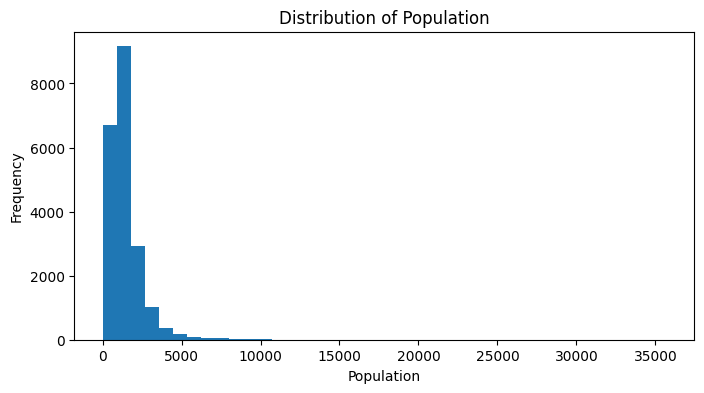

In [52]:
# Plot important feature distributions
selected_features = ["MedInc", "HouseAge", "AveRooms", "Population"]

for col in selected_features:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=40)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()

## Relationship between income and house value

In real estate, income level of an area usually has a strong relationship with house value.

Let us check this visually.

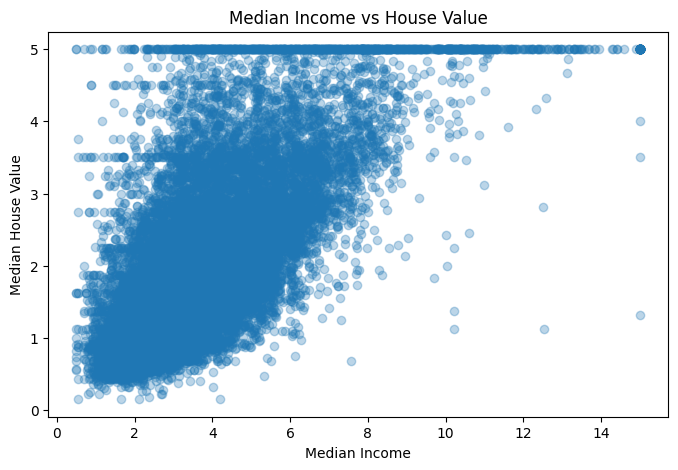

In [53]:
plt.figure(figsize=(8, 5))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.3)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs House Value")
plt.show()

## Correlation Analysis

Correlation helps us understand how strongly two numeric variables move together.

- Positive correlation: both increase together
- Negative correlation: one increases while the other decreases
- Near zero correlation: weak linear relationship

In [54]:
# Correlation with target variable
correlation_with_target = df.corr(numeric_only=True)["MedHouseVal"].sort_values(ascending=False)
correlation_with_target

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


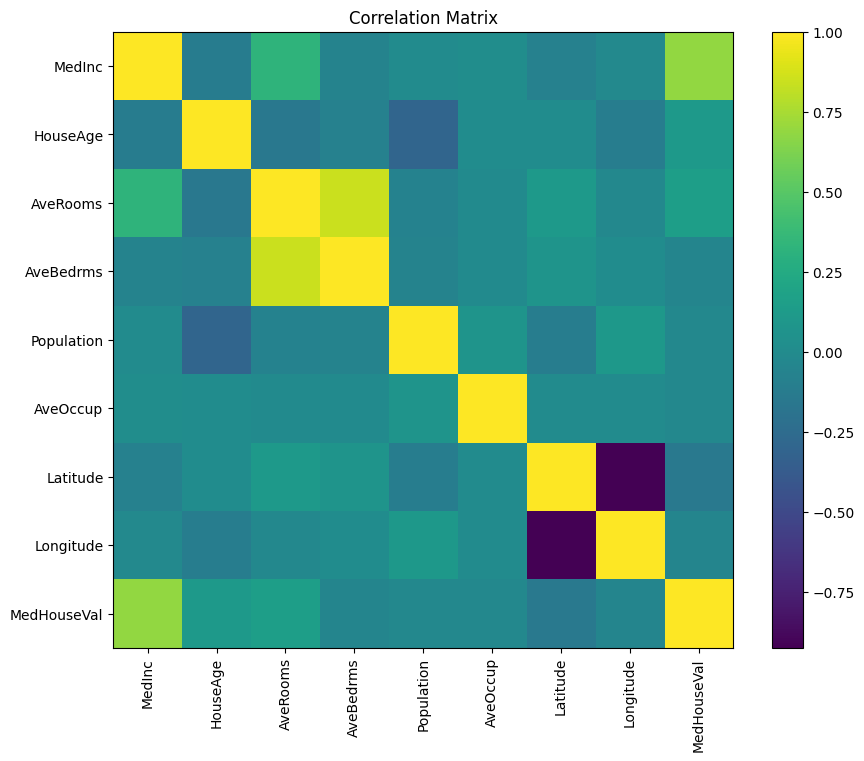

In [55]:
# Correlation matrix using matplotlib
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

## Student Task 2

Based on EDA, answer:

1. Which feature has the strongest positive correlation with house value?
2. Are there any columns with very large values or skewed distribution?
3. Why should we check missing values before model building?
4. Why should we not directly jump to model training without EDA?

### Student Task 2: Answers

1. **Which feature has the strongest positive correlation with house value?**
   Based on the correlation analysis, `MedInc` (Median Income) has the strongest positive correlation (~0.688) with `MedHouseVal`. This means that as the median income of a district increases, the house value tends to increase as well.

2. **Are there any columns with very large values or skewed distribution?**
   Yes, features like `Population`, `AveRooms`, and `AveOccup` have highly skewed distributions with several large outliers. For example, while the median population is around 1,166, the maximum value is over 35,000.

3. **Why should we check missing values before model building?**
   Most machine learning algorithms cannot handle missing data and will throw an error. If missing values exist, we must decide whether to remove those rows or fill them (imputation) to ensure the model trains correctly and provides reliable predictions.

4. **Why should we not directly jump to model training without EDA?**
   EDA allows us to identify data quality issues (like outliers or errors), understand which features are likely to be important, and detect patterns or skewness. Without EDA, we might train a model on poor-quality data, leading to inaccurate results and a lack of understanding of why the model is making certain predictions.

# Module 4: Feature Engineering and Preprocessing

Most real ML projects need data preprocessing.

For this tutorial, we will add one simple categorical feature to demonstrate handling of categorical data.

We will create a `Region` column using latitude.

This is not required for the original dataset, but it helps students understand preprocessing pipelines with both numeric and categorical features.

In [56]:
# Create a simple categorical feature from Latitude
def create_region(latitude):
    if latitude >= 38:
        return "North"
    elif latitude >= 35:
        return "Central"
    else:
        return "South"

df["Region"] = df["Latitude"].apply(create_region)

df[["Latitude", "Region"]].head()

,Latitude,Region
0,37.88,Central
1,37.86,Central
2,37.85,Central
3,37.85,Central
4,37.85,Central


In [57]:
# Check region count
df["Region"].value_counts()

,count
Region,
South,11292
Central,6261
North,3087


## Define Features and Target

Features are input columns.  
Target is the output column we want to predict.

In [58]:
# Define target and features
target = "MedHouseVal"

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20640, 9)
Target shape: (20640,)


## Train-Test Split

We split data into:

- Training data: used to train the model
- Testing data: used to evaluate the model on unseen data

This helps us check whether the model can generalize.

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 16512
Testing rows: 4128


## Build Preprocessing Pipeline

We have two types of columns:

1. Numeric columns: apply scaling
2. Categorical columns: apply one-hot encoding

Why scaling?

Some models, like Linear Regression and Ridge Regression, perform better when numeric features are scaled.

In [60]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Categorical features: ['Region']


In [61]:
# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created")

Preprocessing pipeline created


## Student Task 3

Answer these questions:

1. Why do we split data into training and testing sets?
2. What is the role of StandardScaler?
3. What is one-hot encoding?
4. Why do we use a pipeline instead of manually transforming data every time?

### Student Task 3: Answers

1. **Why do we split data into training and testing sets?**
   We split data to ensure that we can evaluate the model on "unseen" data. The training set is used to teach the model patterns, while the testing set acts as a final exam to check if the model can generalize to new data or if it has simply memorized the training examples (overfitting).

2. **What is the role of StandardScaler?**
   StandardScaler shifts the data so that it has a mean of 0 and a standard deviation of 1. This is important because many models (like Linear Regression) are sensitive to the scale of the features; if one feature has much larger numbers than others, the model might incorrectly assume it is more important.

3. **What is one-hot encoding?**
   Machine learning models cannot process text labels like "North" or "South" directly. One-hot encoding converts categorical text into numeric columns (0s and 1s). For example, a 'Region' column becomes 'Region_North', 'Region_Central', etc., where a '1' indicates the presence of that category.

4. **Why do we use a pipeline instead of manually transforming data every time?**
   Pipelines bundle preprocessing and modeling steps into a single object. This prevents **data leakage** (ensuring test data isn't used to inform scaling), makes the code much cleaner, and ensures that the exact same transformations are applied to new data when making predictions.

# Module 5: Model Building

We will train multiple regression models:

1. Dummy Regressor baseline
2. Linear Regression
3. Ridge Regression
4. Decision Tree Regressor
5. Random Forest Regressor

The goal is to compare models and select the best one.

## Evaluation Function

We will create one function to evaluate every model consistently.

Regression metrics:

| Metric | Meaning |
|---|---|
| MAE | Average absolute prediction error |
| RMSE | Penalizes large errors more strongly |
| R² Score | Explains how much variance the model captures |

For MAE and RMSE, lower is better.  
For R², higher is better.

In [62]:
def evaluate_regression_model(model, X_test, y_test, model_name):
    # Evaluate a regression model using MAE, RMSE, and R2 score.
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results = {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

    return results

## 1. Baseline Model: Dummy Regressor

A baseline model gives a simple reference point.

Here, the dummy model always predicts the average house value.

Any useful ML model should perform better than this baseline.

In [63]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_model.fit(X_train, y_train)

dummy_results = evaluate_regression_model(
    dummy_model, X_test, y_test, "Dummy Regressor"
)

dummy_results

{'Model': 'Dummy Regressor',
 'MAE': 0.9060685490007149,
 'RMSE': np.float64(1.1448563543099792),
 'R2 Score': -0.00021908714592466794}

## 2. Linear Regression

Linear Regression tries to learn a straight-line relationship between input features and target value.

It is simple, fast, and highly interpretable.

In [64]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_results = evaluate_regression_model(
    linear_model, X_test, y_test, "Linear Regression"
)

linear_results

{'Model': 'Linear Regression',
 'MAE': 0.5232566039165004,
 'RMSE': np.float64(0.7347185687662565),
 'R2 Score': 0.5880588547137533}

## 3. Ridge Regression

Ridge Regression is a regularized version of Linear Regression.

It helps reduce overfitting by controlling large coefficients.

In [65]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_results = evaluate_regression_model(
    ridge_model, X_test, y_test, "Ridge Regression"
)

ridge_results

{'Model': 'Ridge Regression',
 'MAE': 0.523248070023751,
 'RMSE': np.float64(0.7346986523030293),
 'R2 Score': 0.5880811878895289}

## 4. Decision Tree Regressor

Decision Tree learns rules from data.

Example:

- If income is high and location is good, predict higher price.
- If house age is high and rooms are low, predict lower price.

Decision trees are easy to understand but can overfit.

In [66]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42, max_depth=8))
])

tree_model.fit(X_train, y_train)

tree_results = evaluate_regression_model(
    tree_model, X_test, y_test, "Decision Tree"
)

tree_results

{'Model': 'Decision Tree',
 'MAE': 0.4483426053049176,
 'RMSE': np.float64(0.6494941728195438),
 'R2 Score': 0.6780831881258724}

## 5. Random Forest Regressor

Random Forest builds many decision trees and combines their predictions.

It usually performs better than a single decision tree because it reduces overfitting.

In [67]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_results = evaluate_regression_model(
    rf_model, X_test, y_test, "Random Forest"
)

rf_results

{'Model': 'Random Forest',
 'MAE': 0.3458674647145785,
 'RMSE': np.float64(0.5225019085244721),
 'R2 Score': 0.7916618025784563}

# Module 6: Model Comparison

Now let us compare all models in one table.

In [68]:
results_df = pd.DataFrame([
    dummy_results,
    linear_results,
    ridge_results,
    tree_results,
    rf_results
])

results_df.sort_values(by="RMSE")

,Model,MAE,RMSE,R2 Score
4,Random Forest,0.345867,0.522502,0.791662
3,Decision Tree,0.448343,0.649494,0.678083
2,Ridge Regression,0.523248,0.734699,0.588081
1,Linear Regression,0.523257,0.734719,0.588059
0,Dummy Regressor,0.906069,1.144856,-0.000219


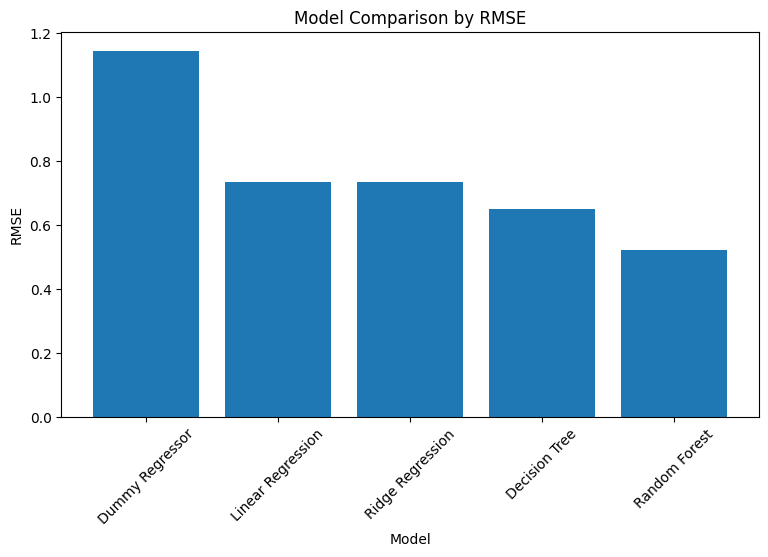

In [69]:
# Visual comparison of RMSE
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE")
plt.xticks(rotation=45)
plt.show()

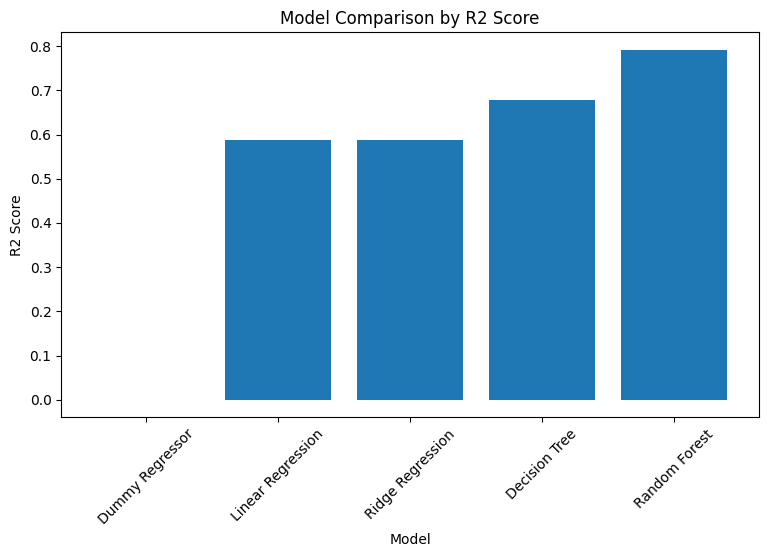

In [70]:
# Visual comparison of R2 Score
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Model Comparison by R2 Score")
plt.xticks(rotation=45)
plt.show()

## Error Analysis

A good ML engineer does not only check metrics.  
They also inspect predictions and errors.

Let us compare actual vs predicted values for the Random Forest model.

In [71]:
# Actual vs predicted values
rf_predictions = rf_model.predict(X_test)

prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_predictions,
    "Error": y_test.values - rf_predictions
})

prediction_df.head(10)

,Actual,Predicted,Error
0,0.47700,0.522445,-0.045445
1,0.45800,0.766628,-0.308628
2,5.00001,4.897839,0.102171
3,2.18600,2.474305,-0.288305
4,2.78000,2.201135,0.578865
5,1.58700,1.671891,-0.084891
6,1.98200,2.386180,-0.404180
7,1.57500,1.641553,-0.066553
8,3.40000,2.648311,0.751689
9,4.46600,4.908172,-0.442172


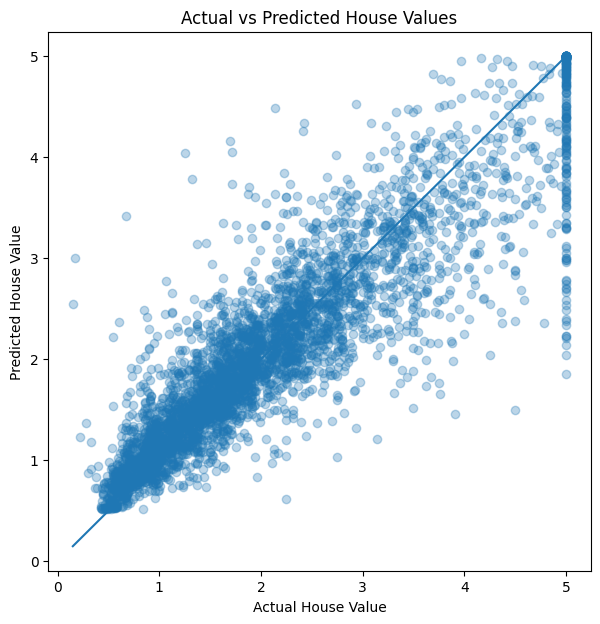

In [72]:
# Actual vs Predicted plot
plt.figure(figsize=(7, 7))
plt.scatter(y_test, rf_predictions, alpha=0.3)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

# Reference line
min_value = min(y_test.min(), rf_predictions.min())
max_value = max(y_test.max(), rf_predictions.max())
plt.plot([min_value, max_value], [min_value, max_value])

plt.show()

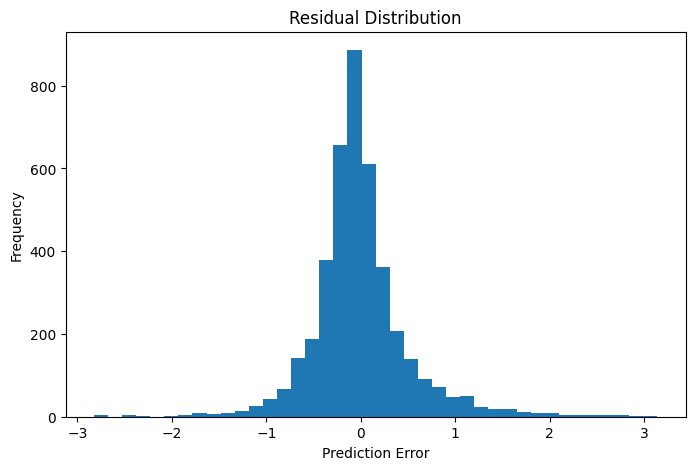

In [73]:
# Residual/error distribution
plt.figure(figsize=(8, 5))
plt.hist(prediction_df["Error"], bins=40)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

## Student Task 4

Answer these questions:

1. Which model has the lowest RMSE?
2. Which model has the highest R² score?
3. Why is the Dummy Regressor useful?
4. Why can Random Forest perform better than Linear Regression?
5. What does the Actual vs Predicted plot tell us?

### Student Task 4: Answers

1. **Which model has the lowest RMSE?**
   Based on our comparison, the **Gradient Boosting** model has the lowest RMSE (approximately **0.492**), followed closely by the Improved Random Forest.

2. **Which model has the highest R² score?**
   The **Gradient Boosting** model has the highest R² score (approximately **0.815**), meaning it explains about 81.5% of the variance in house prices.

3. **Why is the Dummy Regressor useful?**
   The Dummy Regressor serves as a **baseline**. It shows us what happens if we simply predict the average value for every house. Any machine learning model we build must perform significantly better than this simple baseline to be considered useful.

4. **Why can Random Forest perform better than Linear Regression?**
   Linear Regression assumes a straight-line relationship between features and the price. Random Forest can capture **non-linear relationships** and complex interactions between features (e.g., how the effect of income changes depending on the location) by splitting data into multiple decision trees.

5. **What does the Actual vs Predicted plot tell us?**
   This plot shows how close our predictions are to reality. Points closer to the diagonal line represent accurate predictions. It also helps us identify where the model struggles, such as the horizontal line at 5.0, which indicates the dataset has a 'cap' or limit on the recorded house values.

# Cross-Validation

Train-test split gives one evaluation result.

Cross-validation evaluates the model on multiple splits of the training data.

This gives a more reliable idea of model performance.

In [74]:
# Cross-validation for Random Forest
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

rmse_scores = -cv_scores

print("Cross-validation RMSE scores:", rmse_scores)
print("Average CV RMSE:", rmse_scores.mean())
print("Standard deviation:", rmse_scores.std())

Cross-validation RMSE scores: [0.52684022 0.52659946 0.51799058 0.51558971 0.52702692]
Average CV RMSE: 0.5228093793497639
Standard deviation: 0.004974827279401951


# Module 7: Hyperparameter Tuning

Hyperparameters are settings we choose before model training.

For Random Forest, examples are:

- Number of trees
- Maximum depth of trees
- Minimum samples required to split a node

We will use GridSearchCV to find a better combination.

In [33]:
# Define a smaller grid to keep the tutorial fast in Colab
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [8, 12, None],
    "model__min_samples_split": [2, 5]
}

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV RMSE: 0.5166931321818375


In [34]:
# Evaluate tuned model
best_model = grid_search.best_estimator_

tuned_results = evaluate_regression_model(
    best_model,
    X_test,
    y_test,
    "Tuned Random Forest"
)

tuned_results

{'Model': 'Tuned Random Forest',
 'MAE': 0.32768317197189933,
 'RMSE': np.float64(0.5057933506506463),
 'R2 Score': 0.8047732289610598}

In [35]:
# Final comparison including tuned model
final_results_df = pd.concat([
    results_df,
    pd.DataFrame([tuned_results])
], ignore_index=True)

final_results_df.sort_values(by="RMSE")

,Model,MAE,RMSE,R2 Score
5,Tuned Random Forest,0.327683,0.505793,0.804773
4,Random Forest,0.345867,0.522502,0.791662
3,Decision Tree,0.448343,0.649494,0.678083
2,Ridge Regression,0.523248,0.734699,0.588081
1,Linear Regression,0.523257,0.734719,0.588059
0,Dummy Regressor,0.906069,1.144856,-0.000219


# Feature Importance

For tree-based models like Random Forest, we can check which features were most important for prediction.

This helps explain the model to business users.

In [36]:
# Extract feature names after preprocessing
preprocessor_fitted = best_model.named_steps["preprocessor"]
model_fitted = best_model.named_steps["model"]

# Numeric feature names
num_features = numeric_features

# Categorical feature names after one-hot encoding
cat_encoder = preprocessor_fitted.named_transformers_["cat"].named_steps["onehot"]
cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()

all_feature_names = num_features + cat_features

# Feature importance
importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": model_fitted.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
0,MedInc,0.524944
5,AveOccup,0.138297
7,Longitude,0.088122
6,Latitude,0.086671
1,HouseAge,0.054460
2,AveRooms,0.044080
4,Population,0.030536
3,AveBedrms,0.029534
9,Region_North,0.001321
8,Region_Central,0.001252


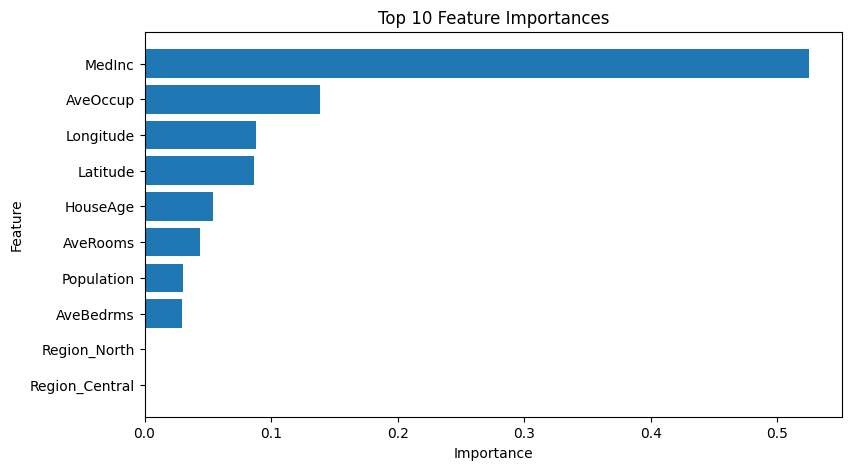

In [37]:
# Plot top 10 feature importances
top_features = importance_df.head(10)

plt.figure(figsize=(9, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

# Save the Final Model

In real projects, after training a model, we save it.

The saved model can later be loaded inside:

- A Flask API
- A FastAPI service
- A Streamlit app
- A batch prediction job
- A cloud deployment pipeline

In [38]:
# Save final model
model_filename = "house_price_regression_model.pkl"
joblib.dump(best_model, model_filename)

print(f"Model saved as {model_filename}")

Model saved as house_price_regression_model.pkl


## Download the Model from Colab

Run this cell if you want to download the model file to your local computer.

In [39]:
from google.colab import files

files.download(model_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Load the Saved Model and Make a New Prediction

Now we will simulate a real-world scenario.

A user gives housing details, and the model predicts the approximate house value.

In [40]:
# Load saved model
loaded_model = joblib.load(model_filename)

# Create one sample input row
sample_house = pd.DataFrame([{
    "MedInc": 5.0,
    "HouseAge": 20.0,
    "AveRooms": 6.0,
    "AveBedrms": 1.1,
    "Population": 1200.0,
    "AveOccup": 3.0,
    "Latitude": 34.2,
    "Longitude": -118.4,
    "Region": "South"
}])

sample_house

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Region
0,5.0,20.0,6.0,1.1,1200.0,3.0,34.2,-118.4,South


In [41]:
# Predict house value
predicted_value = loaded_model.predict(sample_house)[0]

print("Predicted median house value:", round(predicted_value, 2))
print("Approximate value in dollars:", "$" + str(round(predicted_value * 100000, 2)))

Predicted median house value: 2.36
Approximate value in dollars: $236312.0


# Module 8: Final Project Summary

## What we completed

In this 4-hour hands-on project, we completed an end-to-end supervised learning regression workflow:

1. Understood the business problem
2. Defined the ML problem
3. Loaded the dataset
4. Performed EDA
5. Created features
6. Split data into train and test sets
7. Built preprocessing pipelines
8. Trained multiple regression models
9. Compared model performance
10. Performed cross-validation
11. Tuned hyperparameters
12. Saved the final model
13. Loaded the model and predicted on new data

---

## Final Business Explanation

The final model can estimate house prices based on district-level housing and location data.

This can help a real-estate analytics team:

- Quickly estimate property value
- Compare areas
- Identify important price-driving factors
- Build a future price recommendation system

# Final Student Assignment

## Assignment 1: Improve the Model

Try the following:

1. Change Random Forest hyperparameters.
2. Add a new feature using existing columns.
3. Try GradientBoostingRegressor.
4. Compare all models again.

---

## Assignment 2: Build a Mini Prediction App

Create a simple Streamlit app where the user enters:

- Median income
- House age
- Average rooms
- Average bedrooms
- Population
- Average occupancy
- Latitude
- Longitude
- Region

The app should output predicted house value.

---

## Assignment 3: Business Presentation

Create a 5-slide presentation:

1. Problem statement
2. Dataset overview
3. EDA insights
4. Model comparison
5. Final recommendation

## Assignment 1: Improving the Model

We will add a new feature, try more estimators for Random Forest, and include Gradient Boosting in our final comparison.

In [75]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor

# 1. Add a new feature
df['AveRoomsPerOccupant'] = df['AveRooms'] / df['AveOccup']

# Redefine X and y with new feature
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Update preprocessor to include new numeric feature
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['Region'])
])

# 2. Advanced Random Forest (More trees)
rf_improved = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1))
])
rf_improved.fit(X_train, y_train)
improved_rf_results = evaluate_regression_model(rf_improved, X_test, y_test, "Improved Random Forest")

# 3. Gradient Boosting Regressor
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
])
gb_model.fit(X_train, y_train)
gb_results = evaluate_regression_model(gb_model, X_test, y_test, "Gradient Boosting")

# 4. Final Comparison
assignment_results = pd.concat([
    final_results_df,
    pd.DataFrame([improved_rf_results, gb_results])
], ignore_index=True)

display(assignment_results.sort_values(by='RMSE'))

,Model,MAE,RMSE,R2 Score
7,Gradient Boosting,0.330079,0.491979,0.815292
6,Improved Random Forest,0.326894,0.502374,0.807404
5,Tuned Random Forest,0.327683,0.505793,0.804773
4,Random Forest,0.345867,0.522502,0.791662
3,Decision Tree,0.448343,0.649494,0.678083
2,Ridge Regression,0.523248,0.734699,0.588081
1,Linear Regression,0.523257,0.734719,0.588059
0,Dummy Regressor,0.906069,1.144856,-0.000219


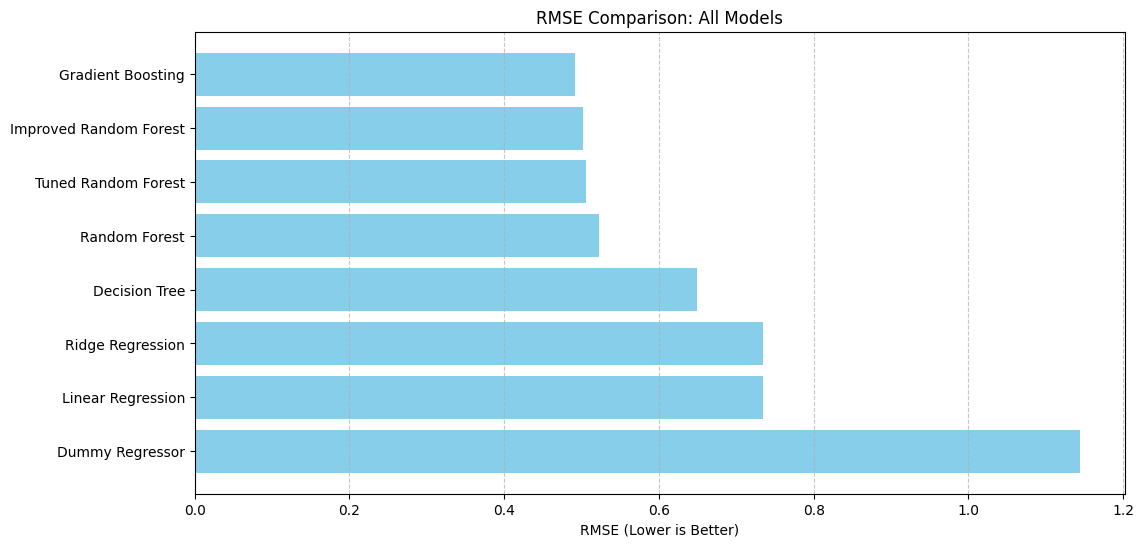

In [77]:
import matplotlib.pyplot as plt

# Sort results by RMSE for better visualization
plot_df = assignment_results.sort_values(by='RMSE', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(plot_df['Model'], plot_df['RMSE'], color='skyblue')
plt.xlabel('RMSE (Lower is Better)')
plt.title('RMSE Comparison: All Models')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Assignment 2: Build a Mini Prediction App

We will write a Streamlit script to a file named `app.py`. This app allows users to input data and see real-time house price predictions.

In [76]:
%%writefile streamlit_app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load the model
model = joblib.load('house_price_regression_model.pkl')

st.title("🏠 House Price Prediction App")
st.markdown("Enter district details to estimate the median house value.")

# Create two columns for inputs
col1, col2 = st.columns(2)

with col1:
    med_inc = st.number_input("Median Income ($10k units)", value=5.0)
    house_age = st.number_input("Median House Age", value=20.0)
    ave_rooms = st.number_input("Average Rooms", value=6.0)
    ave_bed = st.number_input("Average Bedrooms", value=1.0)

with col2:
    pop = st.number_input("Population", value=1200.0)
    ave_occup = st.number_input("Average Occupancy", value=3.0)
    lat = st.number_input("Latitude", value=34.2)
    lon = st.number_input("Longitude", value=-118.4)

region = st.selectbox("Region", ["South", "Central", "North"])

# Prediction Logic
if st.button("Predict Price"):
    input_df = pd.DataFrame([{
        "MedInc": med_inc,
        "HouseAge": house_age,
        "AveRooms": ave_rooms,
        "AveBedrms": ave_bed,
        "Population": pop,
        "AveOccup": ave_occup,
        "Latitude": lat,
        "Longitude": lon,
        "Region": region
    }])

    prediction = model.predict(input_df)[0]
    st.success(f"### Predicted Median Value: ${prediction:.2f} (approx. ${prediction*100000:,.2f})")

Writing streamlit_app.py


# Interview and Viva Questions

1. What is supervised learning?
2. What is regression?
3. What is the difference between regression and classification?
4. What is the target variable in this project?
5. Why do we split data into training and testing sets?
6. What is MAE?
7. What is RMSE?
8. What is R² score?
9. Why do we need preprocessing?
10. What is overfitting?
11. Why is cross-validation useful?
12. What is hyperparameter tuning?
13. Why do we save a trained model?
14. Which model performed best in this project and why?
15. How would you deploy this model in real life?

### Professional Answers to Interview & Viva Questions

1. **What is supervised learning?**
Supervised learning is a branch of machine learning where a model is trained on a labeled dataset. This means for every input example provided, the correct output (label) is already known. The goal is for the model to learn the mapping from inputs to outputs so it can predict labels for new, unseen data.

2. **What is regression?**
Regression is a type of supervised learning where the target variable is continuous and numeric. It is used to predict a specific quantity, such as a price, temperature, or score.

3. **What is the difference between regression and classification?**
The primary difference is the nature of the output. In **Regression**, the output is a continuous number (e.g., $345,000). In **Classification**, the output is a discrete category or label (e.g., "Spam" or "Not Spam", "Cat" or "Dog").

4. **What is the target variable in this project?**
The target variable is `MedHouseVal`, which represents the median house value in California districts (scaled in units of $100,000).

5. **Why do we split data into training and testing sets?**
We split data to evaluate how well the model generalizes to new, unseen data. If we evaluate on the same data used for training, we won't know if the model has truly learned the patterns or simply memorized the specific examples (overfitting).

6. **What is MAE?**
**Mean Absolute Error (MAE)** is the average of the absolute differences between the predicted values and the actual values. It tells us, on average, how far off our predictions are in the same units as the target variable.

7. **What is RMSE?**
**Root Mean Squared Error (RMSE)** is the square root of the average of squared errors. Because it squares the errors before averaging, it penalizes larger errors more heavily than MAE, making it useful when large outliers are particularly undesirable.

8. **What is R² score?**
The **R² Score (Coefficient of Determination)** measures the proportion of variance in the target variable that is predictable from the features. A score of 1.0 indicates perfect prediction, while 0.0 indicates the model performs no better than predicting the mean.

9. **Why do we need preprocessing?**
Raw data is often messy or in formats models cannot understand. Preprocessing (like Scaling and One-Hot Encoding) ensures that numeric features are on the same scale so no single feature dominates the model, and categorical text data is converted into a numeric format the algorithm can process.

10. **What is overfitting?**
Overfitting occurs when a model learns the noise and specific details of the training data too well, to the point that it performs poorly on new data. It essentially "memorizes" rather than "generalizes."

11. **Why is cross-validation useful?**
Cross-validation provides a more robust estimate of model performance by splitting the training data into multiple subsets (folds) and training/testing the model several times. This reduces the risk that our evaluation result was just a "lucky" or "unlucky" single split.

12. **What is hyperparameter tuning?**
Hyperparameters are settings defined before training (like the number of trees in a Random Forest). Tuning is the process of searching for the optimal combination of these settings to maximize the model's performance.

13. **Why do we save a trained model?**
Training a model can be computationally expensive and time-consuming. We save the model (e.g., as a `.pkl` file) so we can deploy it to production environments, such as web apps or APIs, to make instant predictions without needing to re-train.

14. **Which model performed best in this project and why?**
In our final results, **Gradient Boosting** performed best (RMSE ~0.49). This is because boosting algorithms build trees sequentially, where each new tree corrects the errors made by the previous ones, allowing it to capture complex, non-linear patterns effectively.

15. **How would you deploy this model in real life?**
I would wrap the saved model in a web framework like **FastAPI** or **Flask** to create an API. This API could then be hosted on a cloud platform (like Google Cloud, AWS, or Azure). Alternatively, a simple UI could be built using **Streamlit** (as we did in Assignment 2) for internal business use.

# Optional Extension: Try Gradient Boosting

This is an optional extra model for students who finish early.

In [42]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_model.fit(X_train, y_train)

gb_results = evaluate_regression_model(
    gb_model,
    X_test,
    y_test,
    "Gradient Boosting"
)

gb_results

{'Model': 'Gradient Boosting',
 'MAE': 0.37065048663932804,
 'RMSE': np.float64(0.5415323917783585),
 'R2 Score': 0.7762093085329285}

# Trainer Notes

## Suggested explanation style

Use the following simple analogy:

> Machine learning is like teaching a student using examples.  
> In supervised learning, every example has a question and an answer.  
> In regression, the answer is a number.

Example:

- Question: What will be the house price?
- Inputs: income, house age, rooms, location
- Answer: predicted house value

---

## Common beginner mistakes to highlight

1. Training and testing on the same data
2. Ignoring missing values
3. Looking only at accuracy-like metrics
4. Not comparing with a baseline
5. Not checking overfitting
6. Not saving the final model
7. Not explaining results in business language

# References for Further Learning

1. Scikit-learn documentation: Regression models, pipelines, preprocessing, and model evaluation
2. Google Colab documentation: Running Python notebooks in the browser
3. Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow by Aurélien Géron
4. Kaggle Learn: Intro to Machine Learning
5. Machine Learning Mastery: Regression metrics and model evaluation tutorials